In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

import warnings 
warnings.filterwarnings('ignore')

In [2]:
# Load Featured Data 
df = pd.read_csv('data/phishing_featured.csv')
df.shape

(11055, 36)

In [3]:
print("Shape:", df.shape)

Shape: (11055, 36)


In [4]:
# Featured and Label split 
X = df.drop('Result', axis=1)
y = df['Result']

In [5]:
print("Feature Shape:", X.shape)
print("Label Shape:", y.shape)
print("Feature List:", X.columns.tolist())

Feature Shape: (11055, 35)
Label Shape: (11055,)
Feature List: ['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'URL_Suspicious_Score', 'Security_Score', 'Content_Suspicious_Score', 'Domain_Suspicious_Score', 'Total_Phishing_Score']


In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
print("Train Size:", X_train.shape)
print("Test Size:", X_test.shape)

Train Size: (8844, 35)
Test Size: (2211, 35)


In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling Done Successfully!")
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

Scaling Done Successfully!
X_train Shape: (8844, 35)
X_test Shape: (2211, 35)


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f"{name}: {acc*100:.2f}%")

Logistic Regression: 92.40%
Random Forest: 96.92%
XGBoost: 94.75%
SVM: 95.21%


              precision    recall  f1-score   support

          -1       0.97      0.95      0.96       956
           1       0.97      0.98      0.97      1255

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



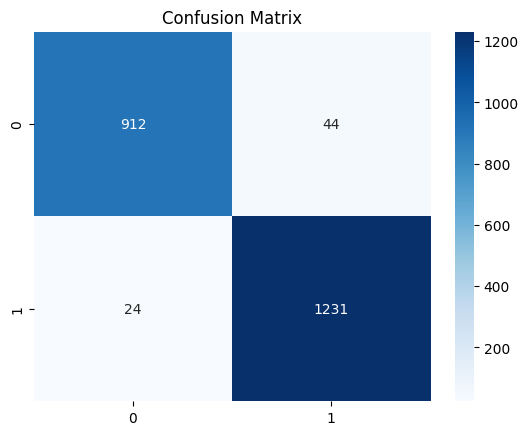

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Random Forest best model hai
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Classification Report
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_*100, "%")

Best Parameters: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 96.91315235491075 %


In [16]:
import pickle
import os
os.makedirs('models', exist_ok=True)
best_model = grid_search.best_estimator_

with open('models/phishing_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model Saved Successfully!")
print("Scaler Saved Successfully!")

Model Saved Successfully!
Scaler Saved Successfully!
